# Netflix Movies & TV Shows – Exploratory Data Analysis
**Pluto Academy Internship Project 01**

This project performs Exploratory Data Analysis (EDA) on the Netflix dataset to understand content patterns, trends, and generate insights.

## Step 1 — Load & Inspect the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
df = pd.read_csv("netflix_titles.csv")

# Display the first few rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [2]:
# Check shape
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (7787, 12)


In [3]:
# Check data types
print("Data Types:\n", df.dtypes)

Data Types:
 show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object


In [4]:
# Check missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64


In [5]:
# Check duplicates
print(f"Duplicate Rows: {df.duplicated().sum()}")

Duplicate Rows: 0


### Data Summary
1. The dataset contains 7,787 rows and 12 columns, representing different movies and TV shows on Netflix.
2. It includes features like title, type (Movie/TV Show), director, cast, country, date added, release year, rating, duration, and listed_in (genre).
3. There are missing values primarily in the `director`, `cast`, and `country` columns.
4. A few columns like `date_added` are currently strings and need conversion to datetime.
5. There are no completely duplicated rows in the dataset.

## Step 2 — Clean the Data
**Cleaning Decisions Documented:**
1. **Handle Missing Values:** 
   - `director` and `cast` have too many missing values and are highly distinct, so we will fill them with "Unknown".
   - `country` has missing values, which we will fill with the mode (most common country).
   - `date_added` and `rating` have very few missing values, so we will drop the rows with missing values in these columns.
2. **Fix Data Types:**
   - Convert `date_added` to a datetime object to extract the year and month.
3. **Remove Irrelevant Columns:**
   - Drop `show_id` as it is just a unique identifier and holds no analytical value.
4. **Feature Engineering:**
   - Create a `year_added` column from `date_added`.
   - Create a numeric `duration_num` column from `duration` for Movies.

In [6]:
# Fill missing values for 'director' and 'cast'
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

# Fill missing values for 'country' with mode
df['country'] = df['country'].fillna(df['country'].mode()[0])

# Drop rows with missing 'date_added' and 'rating'
df.dropna(subset=['date_added', 'rating'], inplace=True)

# Drop 'show_id'
df.drop(columns=['show_id'], inplace=True)

# Convert 'date_added' to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y', errors='coerce')

# Create 'year_added' column
df['year_added'] = df['date_added'].dt.year

# Create 'duration_num' (extract number from duration)
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

print("Missing values after cleaning:\n", df.isnull().sum())

Missing values after cleaning:
 type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
duration_num    0
dtype: int64


<>:21: SyntaxWarning: invalid escape sequence '\d'
<>:21: SyntaxWarning: invalid escape sequence '\d'
C:\Users\shaur\AppData\Local\Temp\ipykernel_2276\281289550.py:21: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


## Step 3 — Exploratory Data Analysis

**Q1. What is the ratio of Movies to TV Shows?**

In [7]:
type_counts = df['type'].value_counts(normalize=True) * 100
print(type_counts)

type
Movie      69.137709
TV Show    30.862291
Name: proportion, dtype: float64


**Q2. What are the top 5 countries producing content?**

In [8]:
top_countries = df['country'].value_counts().head(5)
print(top_countries)

country
United States     3051
India              923
United Kingdom     396
Japan              224
South Korea        183
Name: count, dtype: int64


**Q3. What is the trend of content added over the years?**

In [9]:
yearly_trend = df['year_added'].value_counts().sort_index()
print(yearly_trend)

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      25
2015      88
2016     440
2017    1222
2018    1684
2019    2153
2020    2009
2021     117
Name: count, dtype: int64


**Q4. Which are the top 5 most common ratings?**

In [10]:
top_ratings = df['rating'].value_counts().head(5)
print(top_ratings)

rating
TV-MA    2861
TV-14    1928
TV-PG     804
R         665
PG-13     386
Name: count, dtype: int64


**Q5. What are the top 5 oldest movies on Netflix?**

In [11]:
oldest_movies = df[df['type'] == 'Movie'].sort_values('release_year').head(5)[['title', 'release_year']]
print(oldest_movies)

                                              title  release_year
4960                                 Prelude to War          1942
6117                           The Battle of Midway          1942
7342  Undercover: How to Operate Behind Enemy Lines          1943
7679                WWII: Report from the Aleutians          1943
7616             Why We Fight: The Battle of Russia          1943


## Step 4 — Visualizations

C:\Users\shaur\AppData\Local\Temp\ipykernel_2276\1894149246.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')


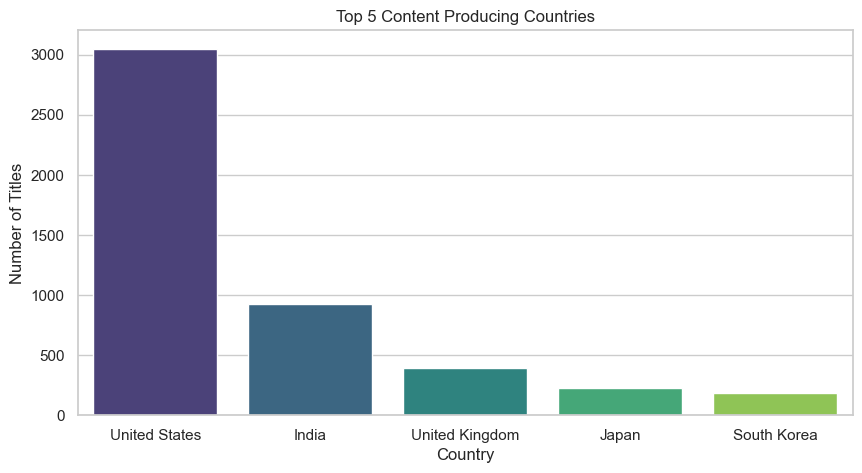

In [12]:
# 1. Bar Chart: Top 5 countries producing content
plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')
plt.title('Top 5 Content Producing Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.show()

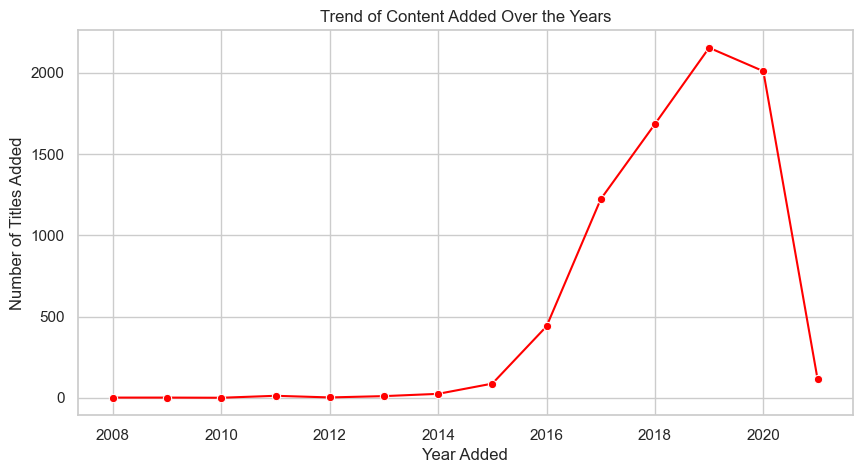

In [13]:
# 2. Line Chart: Trend of content added over the years
plt.figure(figsize=(10, 5))
sns.lineplot(x=yearly_trend.index, y=yearly_trend.values, marker='o', color='red')
plt.title('Trend of Content Added Over the Years')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.show()

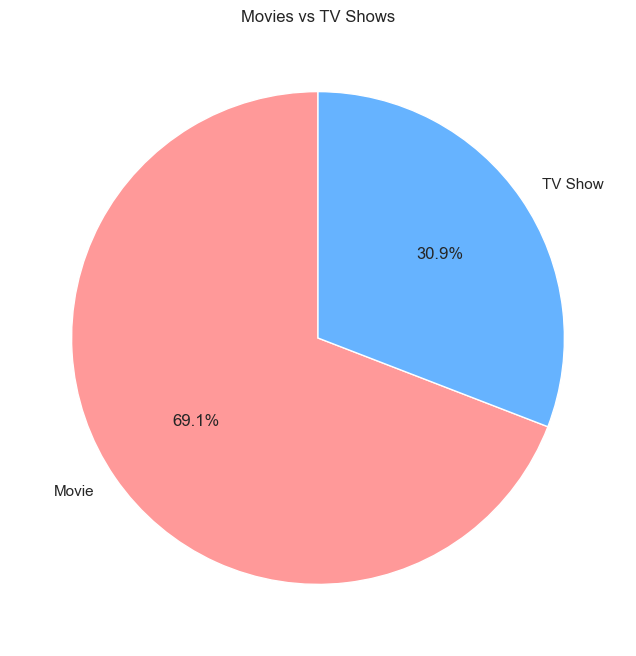

In [14]:
# 3. Pie Chart: Ratio of Movies vs TV Shows
plt.figure(figsize=(8, 8))
plt.pie(df['type'].value_counts(), labels=df['type'].value_counts().index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Movies vs TV Shows')
plt.show()

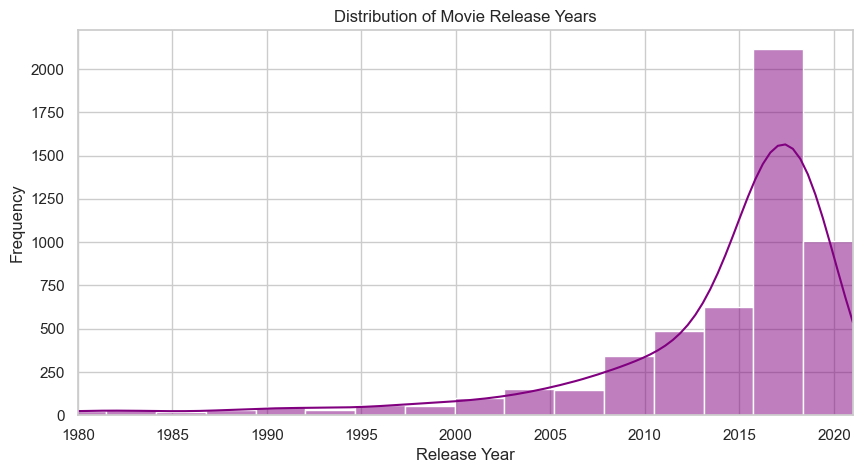

In [15]:
# 4. Histogram: Distribution of release years for Movies
movies_df = df[df['type'] == 'Movie']
plt.figure(figsize=(10, 5))
sns.histplot(movies_df['release_year'], bins=30, kde=True, color='purple')
plt.title('Distribution of Movie Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.xlim(1980, 2021)
plt.show()

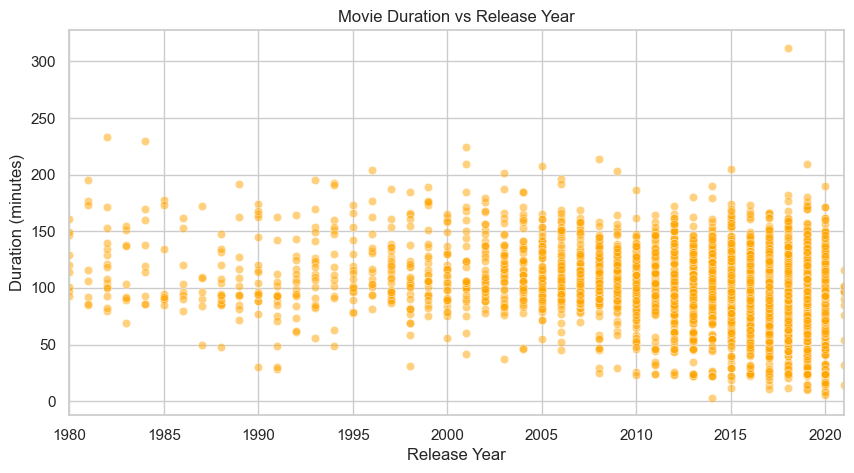

In [16]:
# 5. Scatter Plot: Release Year vs Duration (Movies)
plt.figure(figsize=(10, 5))
sns.scatterplot(data=movies_df, x='release_year', y='duration_num', alpha=0.5, color='orange')
plt.title('Movie Duration vs Release Year')
plt.xlabel('Release Year')
plt.ylabel('Duration (minutes)')
plt.xlim(1980, 2021)
plt.show()

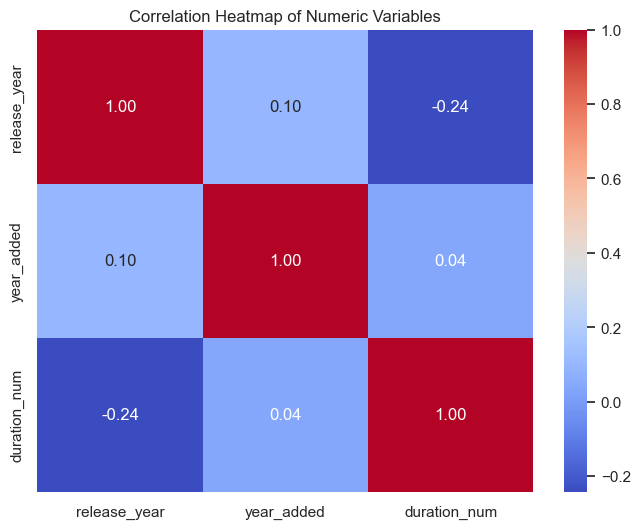

In [17]:
# 6. Heatmap: Correlation Matrix
plt.figure(figsize=(8, 6))
numeric_cols = df[['release_year', 'year_added', 'duration_num']].dropna()
correlation = numeric_cols.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

## Step 5 — Insights Report

1. **Content Strategy Focus**: The pie chart shows that Movies (~69%) dominate the Netflix platform compared to TV Shows (~31%), suggesting Netflix historically prioritized licensing and producing feature-length films over episodic series.
2. **Global Production Hubs**: The bar chart indicates that the United States is by far the largest producer of Netflix content, followed distantly by India, highlighting Netflix's strong focus on the US market and its significant investment in Bollywood and Indian regional content.
3. **Rapid Growth Era**: The line chart visualizes a massive exponential surge in content additions starting around 2015, peaking in 2019, which aligns with Netflix's aggressive global expansion and original content strategy during those years.
4. **Recent Content Bias**: The histogram of release years shows a heavy left-skew, meaning the vast majority of movies available on the platform were released in the last decade (post-2010), showing a preference for newer, modern content rather than classics.
5. **Duration Trends**: The scatter plot reveals that while standard movie durations typically range between 90 and 120 minutes, there are many outliers (short documentaries and very long epics), but the average duration has remained relatively consistent over the decades.

### Most Surprising Finding
The most surprising finding was the steep drop-off in content added after 2019 in the line chart. While one might expect continuous exponential growth, the data clearly shows a plateau and decline, likely reflecting the impact of the COVID-19 pandemic on global production schedules or a shift in strategy from quantity to quality.